# The PBoC RRR Effect — a quantitative teardown 🔬
### Cut/hike Welch-HAC splits · a one-sided 20-seed placebo · the [-5..+10] event anatomy · an MCHI cross-check · the era contrast · a buy-the-cut timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Buy_the_rumor%2C_sell_the_news%3F: Busted](https://img.shields.io/badge/Buy_the_rumor%2C_sell_the_news%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Chinese equities pop on a PBoC RRR cut** — is repeated financial-press folklore with a plausible mechanism (freed lending capacity) but, unlike the FOMC-vol-crush or BoJ siblings, no dedicated peer-reviewed event-study anchor. The job here is to measure it honestly, with its own unstated mirror (hikes should be bearish) tested just as hard.

> ⚠️ **Data note.** FXI daily raw OHLC + adjusted close (2008 → 2026) + MCHI (2011 → 2026, cross-check), yfinance, cached; **48 hardcoded broad-based PBoC RRR announcements** (31 cuts, 17 hikes) from the PBoC's official archive, cross-checked against financial-press coverage — targeted/structural relief excluded by construction. No survivorship on the Signal axis (fund tapes); **FXI's swap-heavy QFII-quota structure is named on Tradability**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `d41690523582` / `460c227db0e1`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pboc_rrr_effect import data, strategy as st

RRR = data.rrr_frame()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    FXI, MCHI = data.load_real()
    MATCHED_FXI = st.match_trading_days(FXI.index, RRR)
    MATCHED_MCHI = st.match_trading_days(MCHI.index, RRR)
    DF = st.day_frame(FXI, MATCHED_FXI)
    MDF = st.day_frame(MCHI, MATCHED_MCHI)
    CUT_DAYS = pd.DatetimeIndex(MATCHED_FXI.loc[MATCHED_FXI["direction"] == "cut", "trading_date"])
else:
    FXI = MCHI = DF = MDF = MATCHED_FXI = CUT_DAYS = None
print("real cache present:", HAVE_REAL, "| RRR announcements:", len(RRR),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-01-01', 'end': '2026-06-30', 'n_events': 48, 'n_cut': 31, 'n_hike': 17, 'cal_lo': '2008-01-16', 'cal_hi': '2025-05-07', 'cut_pct': 0.7145, 'cut_rest_pct': -0.0079, 'cut_gap': 0.7225, 'cut_t': 0.99, 'cut_nw': 1.0, 'cut_hit': 20, 'cut_n': 31, 'cut_hit_pct': 64.5, 'cut_wilson': (46.9, 78.9), 'hike_pct': 0.6397, 'hike_rest_pct': -0.0055, 'hike_gap': 0.6452, 'hike_t': 1.36, 'hike_nw': 1.4, 'hike_hit': 13, 'hike_n': 17, 'hike_hit_pct': 76.5, 'hike_wilson': (52.7, 90.4), 'cvh_t': 0.09, 'placebo_cut_p': 0.0296, 'placebo_cut_mean': -0.0057, 'placebo_cut_sd': 0.3682, 'placebo_hike_p': 0.9132, 'placebo_hike_mean': -0.009, 'placebo_hike_sd': 0.4953, 'event': {-5: (-0.184, -0.36), -4: (-0.7631, -1.3), -3: (0.366, 0.64), -2: (0.0092, 0.0), -1: (-0.6345, -1.08), 0: (0.7145, 0.96), 1: (0.4567, 0.77), 2: (-0.5126, -0.76), 3: (1.0035, 1.58), 4: (-0.5204, -1.06), 5: (-0.4434, -0.88), 6: (-0.3196, -0.85), 7: (-0.613, -0.84), 8: (-0.6753, -1.32), 9: (1.3584, 1.87), 10: (-0.7219, -1.97)}, 'runup_pct': -1.206, 'runup_t': -0.97, 'runup_n': 31, 'post_pct': -0.943, 'post_t': -0.71, 'post_n': 31, 'range_event': 2.1772, 'range_rest': 1.49, 'range_t': 2.45, 'mchi_cut_n': 27, 'mchi_cut_pct': 0.9768, 'mchi_cut_rest': 0.0008, 'mchi_cut_t': 1.98, 'mchi_hike_n': 3, 'mchi_hike_pct': 0.9219, 'mchi_hike_rest': 0.0069, 'mchi_hike_t': 2.59, 'mchi_cvh_t': 0.09, 'era_early_pct': -0.3898, 'era_early_n': 7, 'era_early_t': -0.13, 'era_late_pct': 1.0366, 'era_late_n': 24, 'era_late_t': 2.1, 'era_diff_t': 0.49, 'timer': {1: (71.5, 61.5, 1.7, 0.95, 64.5, -16.1), 3: (65.9, 55.9, 7.3, 0.57, 61.3, -15.9), 5: (111.8, 101.8, 14.3, 0.87, 54.8, -15.9), 10: (30.1, 20.1, 30.4, -0.0, 58.1, -29.8)}, 'syn_null_mean': -0.15, 'syn_null_sd': 1.22, 'syn_null_fire': 2, 'syn_planted_t': 4.13, 'fp_fxi': 'd41690523582', 'fp_mchi': '460c227db0e1'}


real cache present: True | RRR announcements: 48 | tape days: 4651


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | cut-day *t* = 0.99, hike-day *t* = 1.36; **cuts vs hikes, Welch *t* = 0.09** (MCHI confirms: 0.09) |
| **Tradability** | `MIRAGE` | buy-the-cut timer never clears *t* = 2 (best 0.95); 10-day hold *t* = -0.00 vs a random window |
| **Rumor/news?** | `BUSTED` | pre-cut run-up *t* = -0.97 (negative); post-cut window *t* = -0.71 |

> 💡 In plain words: RRR announcement days are louder than average, but the loudness has no sign attached to it — cuts and hikes look the same.

## 1 · The claim, steelmanned

Let $r_t$ be FXI's daily log return and $C_t, H_t \in \{0,1\}$ the scheduled cut-day / hike-day flags from the hardcoded, broad-based RRR calendar. The claims:

- **H₁ (cut pop).** $E[r_t \mid C_t=1] \gg E[r_t \mid C_t=0]$.
- **H₂ (hike drop, the unstated mirror).** $E[r_t \mid H_t=1] \ll E[r_t \mid H_t=0]$.
- **H₃ (direction matters).** $E[r_t \mid C_t=1] \ne E[r_t \mid H_t=1]$, tested *directly* — the cleanest single falsification available.
- **H₄ (rumor/news timing).** A pre-cut run-up (rumor) and a post-cut fade (news) inside the [-5..+10] window.
- **H₅ (capture).** A prior-close-to-close FXI hold over the cut day (or several days) banks it net of costs.

We find **H₁ unsupported at the primary bar** (*t* = 0.99), **H₂ flatly rejected** (hike days are POSITIVE, *t* = 1.36, same sign as cuts), **H₃ decisively rejected** (*t* = 0.09, replicated on MCHI), **H₄ rejected** (run-up is negative, no clean fade), **H₅ not certified** at any horizon.

## 2 · So what? — inference design

RRR events are **single, non-overlapping-in-theory events** (median spacing is months), so the planned primary is a **Welch t** on each group split — but the single most informative statistic on this desk's own terms is the **direct cuts-vs-hikes Welch t**, which needs no assumption about what an "ordinary day" looks like: if the claim's own mechanism (direction) is doing the work, that gap should be large. A **Newey-West (5-lag) t** cross-checks the day-level splits; the placebo is **one-sided** with a pre-committed tail per direction (the claim has a sign, unlike a symmetric-surprise story); MCHI replicates every number on a differently constructed index to rule out FXI-specific microstructure; and the era split (2015-01-01, the RRR's regime pivot from hiking to a near-permanent cutting stance) is tested as a **difference**, not eyeballed.

## 3 · How we'd know — the protocol

- **Calendar.** 48 broad-based announcements 2008-01-16 → 2025-05-07 (31 cuts, 17 hikes), hardcoded, all mapping onto the FXI tape.
- **Tape.** FXI raw OHLC + adjusted close 2008-01-01 → 2026-06-30; MCHI from its 2011-03-29 inception (cross-check). As-of 2026-06-30 (last complete month).
- **Headline.** Welch t + NW(5) t + Wilson hit rate + one-sided 20-seed placebo, cut and hike each vs the rest; then the direct cuts-vs-hikes Welch t.
- **Anatomy.** Event window [-5..+10] (cut days), per-offset Welch t vs far days; cumulative pre/post-window one-sample t's.
- **Cross-check.** MCHI replicates the whole headline split, modern era only.
- **Execution (third axis).** Enter FXI at the prior close relative to the announcement's mapped trading day (zero look-ahead — see docs/results.md), hold 1/3/5/10 days, exit; 2 x one-way cost x NAV per event; long-only, no borrow.
- **Control.** Synthetic i.i.d.-return world, planted cut-day mean-shift knob; the null must not (systematically) fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split, and the test that actually decides it

Welch t + NW(5) t + Wilson hit rate for cuts and hikes, each vs an ordinary day — then the direct cuts-vs-hikes Welch t, the single most informative number here.

 cut: +0.7145% vs -0.0079%   Welch t=+0.99  NW t=+1.00  hit 20/31=64.5% [46.9%,78.9%]
hike: +0.6397% vs -0.0055%   Welch t=+1.36  NW t=+1.40  hit 13/17=76.5% [52.7%,90.4%]
cuts vs hikes, direct: cut +0.7145%  hike +0.6397%   Welch t = +0.09


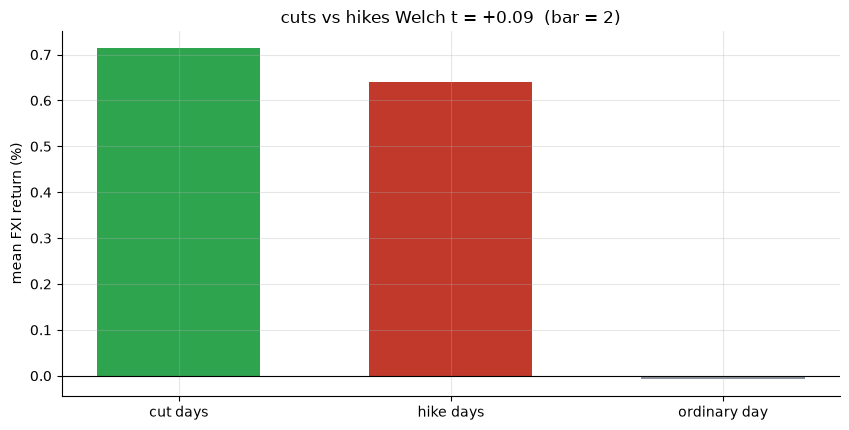

In [2]:
if HAVE_REAL:
    sc = st.decision_day_stats(DF, 'ret', 'cut')
    sh = st.decision_day_stats(DF, 'ret', 'hike')
    cvh = st.cuts_vs_hikes(DF, 'ret')
else:
    sc = dict(event_pct=R['cut_pct'], rest_pct=R['cut_rest_pct'], welch_t=R['cut_t'],
              nw_t=R['cut_nw'], hit_up=R['cut_hit'], n_event=R['cut_n'],
              hit_rate=R['cut_hit_pct']/100, hit_lo=R['cut_wilson'][0]/100,
              hit_hi=R['cut_wilson'][1]/100)
    sh = dict(event_pct=R['hike_pct'], rest_pct=R['hike_rest_pct'], welch_t=R['hike_t'],
              nw_t=R['hike_nw'], hit_up=R['hike_hit'], n_event=R['hike_n'],
              hit_rate=R['hike_hit_pct']/100, hit_lo=R['hike_wilson'][0]/100,
              hit_hi=R['hike_wilson'][1]/100)
    cvh = dict(cut_pct=R['cut_pct'], hike_pct=R['hike_pct'], welch_t=R['cvh_t'])
for label, s in (('cut', sc), ('hike', sh)):
    print(f"{label:>4}: {s['event_pct']:+.4f}% vs {s['rest_pct']:+.4f}%   "
          f"Welch t={s['welch_t']:+.2f}  NW t={s['nw_t']:+.2f}  "
          f"hit {s['hit_up']}/{s['n_event']}={s['hit_rate']*100:.1f}% "
          f"[{s['hit_lo']*100:.1f}%,{s['hit_hi']*100:.1f}%]")
print(f"cuts vs hikes, direct: cut {cvh['cut_pct']:+.4f}%  hike "
      f"{cvh['hike_pct']:+.4f}%   Welch t = {cvh['welch_t']:+.2f}")
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['cut days', 'hike days', 'ordinary day'],
       [sc['event_pct'], sh['event_pct'], sc['rest_pct']],
       color=[GREEN, RED, GREY], width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean FXI return (%)')
ax.set_title(f"cuts vs hikes Welch t = {cvh['welch_t']:+.2f}  (bar = 2)")
plt.tight_layout(); plt.show()

> 💡 In plain words: neither the cut split (*t* = 0.99) nor the hike split (*t* = 1.36) individually clears the bar, but the number that matters most is **cuts vs hikes = 0.09** — direction explains almost nothing. Both kinds of announcement day are hotter than an ordinary day; neither is hotter than the other.

### 4b · The one-sided placebo

Pre-committed sign per direction: cuts should beat a random calendar from ABOVE (right tail), hikes from BELOW (left tail). Null pool excludes ALL RRR days.

In [3]:
if HAVE_REAL:
    pl_c = st.placebo_pvalue(DF, 'ret', 'cut', tail='right',
                             n_draws_per_seed=250, n_seeds=4)
    pl_h = st.placebo_pvalue(DF, 'ret', 'hike', tail='left',
                             n_draws_per_seed=250, n_seeds=4)
    obs_c, obs_h = pl_c['obs'], pl_h['obs']
else:
    rng = np.random.default_rng(647)
    obs_c, obs_h = R['cut_pct']/100, R['hike_pct']/100
    pl_c = dict(placebo_mean=R['placebo_cut_mean']/100, placebo_sd=R['placebo_cut_sd']/100)
    pl_h = dict(placebo_mean=R['placebo_hike_mean']/100, placebo_sd=R['placebo_hike_sd']/100)
print(f"cut  (right tail): canonical p = {R['placebo_cut_p']:.4f} "
      f"(obs {R['cut_pct']:+.4f}% vs placebo mean {R['placebo_cut_mean']:+.4f}%, "
      f"sd {R['placebo_cut_sd']:.4f}%)")
print(f"hike (left  tail): canonical p = {R['placebo_hike_p']:.4f} "
      f"(obs {R['hike_pct']:+.4f}% vs placebo mean {R['placebo_hike_mean']:+.4f}%, "
      f"sd {R['placebo_hike_sd']:.4f}%)")

cut  (right tail): canonical p = 0.0296 (obs +0.7145% vs placebo mean -0.0057%, sd 0.3682%)
hike (left  tail): canonical p = 0.9132 (obs +0.6397% vs placebo mean -0.0090%, sd 0.4953%)


> 💡 In plain words: the cut placebo's canonical *p* = 0.0296 looks more impressive than its Welch *t* — a small, slightly right-skewed sample can do that. It doesn't survive the cuts-vs-hikes wash test above (4a), which is why the certified verdict is `NONE`, not `WEAK`. The hike placebo's *p* = 0.9132 flatly rejects the tightening half of the folklore — hike days are nowhere near the bottom of a random calendar.

### 4c · Event anatomy — is there a shape at all?

Per-offset means with Welch t vs far-from-event days, cut days only [-5..+10].

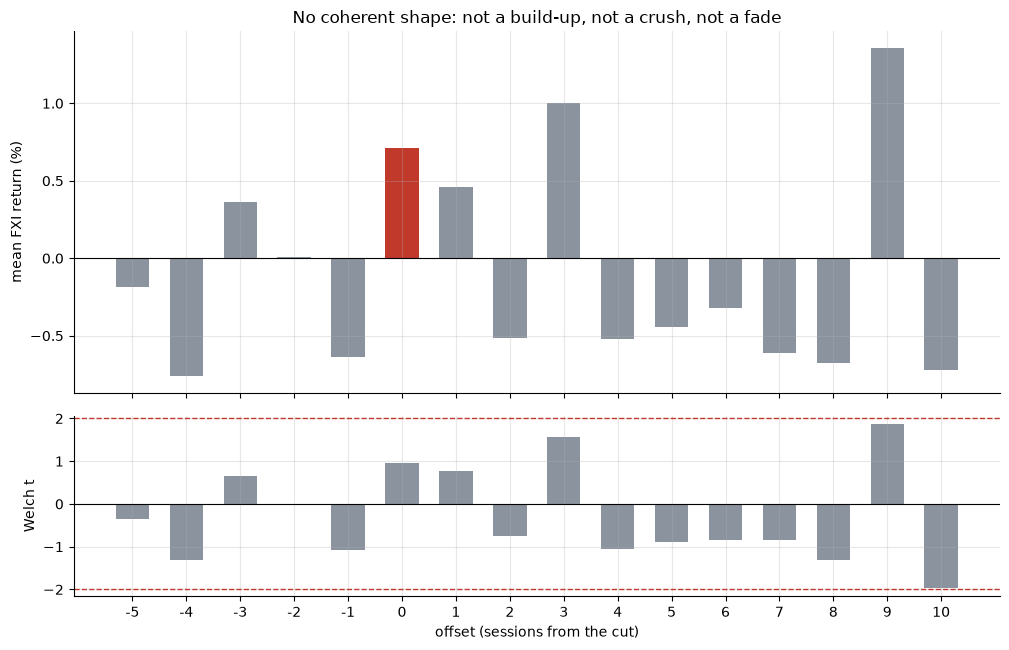

pre-cut run-up [-5..-1]: -1.206%/event (t=-0.97)
post-cut window [+1..+10]: -0.943%/event (t=-0.71)


In [4]:
if HAVE_REAL:
    ev = st.event_study(DF, 'ret', CUT_DAYS)
    ks = list(ev.index); ms = list(ev['mean_pct']); ts = list(ev['welch_t'])
    ru = st.runup_stats(DF, 'ret', CUT_DAYS); pe = st.postevent_stats(DF, 'ret', CUT_DAYS)
    ru_m, ru_t, pe_m, pe_t = ru['mean_runup_pct'], ru['t'], pe['mean_postrun_pct'], pe['t']
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
    ts = [R['event'][k][1] for k in ks]
    ru_m, ru_t, pe_m, pe_t = R['runup_pct'], R['runup_t'], R['post_pct'], R['post_t']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
cols = [RED if k == 0 else GREY for k in ks]
a1.bar([str(k) for k in ks], ms, color=cols, width=.62)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean FXI return (%)')
a1.set_title('No coherent shape: not a build-up, not a crush, not a fade')
a2.bar([str(k) for k in ks], ts, color=[RED if abs(t) >= 2 else GREY for t in ts], width=.62)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_xlabel('offset (sessions from the cut)')
plt.tight_layout(); plt.show()
print(f'pre-cut run-up [-5..-1]: {ru_m:+.3f}%/event (t={ru_t:+.2f})')
print(f'post-cut window [+1..+10]: {pe_m:+.3f}%/event (t={pe_t:+.2f})')

> 💡 In plain words: the pre-cut run-up is **-1.21%** at *t* = -0.97 — *negative*, the opposite of "buy the rumor." The post-cut window is **-0.94%** at *t* = -0.71 — mildly negative, not a clean decay from a certified pop (there's no certified pop to decay from). The one lone offset that individually crosses \|t\| ≥ 2 (day +10, *t* = -1.97) runs the WRONG sign for a "news gets sold" story to claim credit for, and at 16 tested offsets one crossing 2 by chance is expected, not notable.

### 4d · MCHI cross-check — same result, a differently built index

MCHI (broad China ETF, 2011 inception) replicates the whole headline split, modern-era events only.

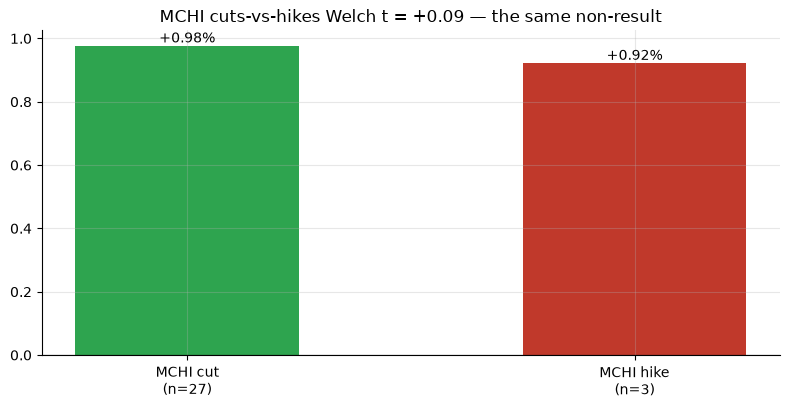

MCHI cut +0.977%  hike +0.922%   cuts-vs-hikes t = +0.09


In [5]:
if HAVE_REAL:
    smc = st.decision_day_stats(MDF, 'ret', 'cut')
    smh = st.decision_day_stats(MDF, 'ret', 'hike')
    cvhm = st.cuts_vs_hikes(MDF, 'ret')
    cp_m, hp_m, tm = smc['event_pct'], smh['event_pct'], cvhm['welch_t']
else:
    cp_m, hp_m, tm = R['mchi_cut_pct'], R['mchi_hike_pct'], R['mchi_cvh_t']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['MCHI cut\n(n=27)', 'MCHI hike\n(n=3)'], [cp_m, hp_m], color=[GREEN, RED], width=.5)
for i, v in enumerate([cp_m, hp_m]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_title(f'MCHI cuts-vs-hikes Welch t = {tm:+.2f} — the same non-result')
plt.tight_layout(); plt.show()
print(f'MCHI cut {cp_m:+.3f}%  hike {hp_m:+.3f}%   cuts-vs-hikes t = {tm:+.2f}')

> 💡 In plain words: MCHI's cuts-vs-hikes Welch *t* = 0.09 — the identical non-result on an independently constructed index. The MCHI hike split alone crosses *t* = 2.59, but on only **n = 3** events (all from spring 2011, before MCHI had much history) — nowhere near enough to certify anything on its own, and it doesn't change the cuts-vs-hikes conclusion, which uses the same three hikes and still washes out against cuts.

### 4e · Era contrast — panic-easing (2008-2012) vs secular grind (2015-2025), cut days only

Split at **2015-01-01**, justified ex ante: the RRR's last hike was June 2011; every cut since 2015 has been well telegraphed days ahead by State Council meetings, vs the more acute 2008-2012 crisis pivots.

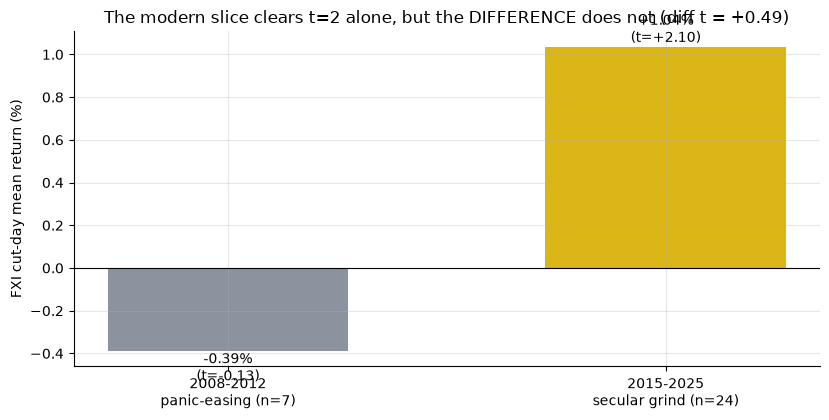

early -0.390% (t=-0.13)  late +1.037% (t=+2.10)  diff t=+0.49


In [6]:
if HAVE_REAL:
    ec = st.era_contrast(DF, 'ret', data.ZERO_RATE_ERA_SPLIT)
    e, l = ec['early_pct'], ec['late_pct']
    et, lt, dt = ec['welch_t_early'], ec['welch_t_late'], ec['welch_t_diff']
else:
    e, l = R['era_early_pct'], R['era_late_pct']
    et, lt, dt = R['era_early_t'], R['era_late_t'], R['era_diff_t']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['2008-2012\npanic-easing (n=7)', '2015-2025\nsecular grind (n=24)'], [e, l],
       color=[GREY, AMBER], width=.55)
for i, (v, t_) in enumerate([(e, et), (l, lt)]):
    ax.annotate(f'{v:+.2f}%\n(t={t_:+.2f})', (i, v), ha='center',
                va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('FXI cut-day mean return (%)')
ax.set_title(f'The modern slice clears t=2 alone, but the DIFFERENCE does not '
             f'(diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e:+.3f}% (t={et:+.2f})  late {l:+.3f}% (t={lt:+.2f})  diff t={dt:+.2f}')

> 💡 In plain words: the 2015-2025 cut slice alone crosses the bar (*t* = 2.10, n = 24) — the single closest thing to a "real" number in this whole study. But the difference between the two eras is **not certified** (*t* = 0.49), the early-era *n* is tiny (7), and — decisively — the SAME modern era shows no directional signature at all once hikes are brought back into the comparison (4a/4d). Read honestly: the modern cut window overlaps several broad China-equity bull legs (2015 rally, 2019-2021 recovery) — consistent with clustering, not a certified announcement effect.

### 4f · The third axis — the buy-the-cut timer, with costs

Enter FXI at the prior close, hold 1/3/5/10 trading days, exit; 2 x one-way cost (5 bps) x NAV per round trip. Rest-of-tape null: every same-horizon rolling window that doesn't touch any RRR event's [-5..+10] window.

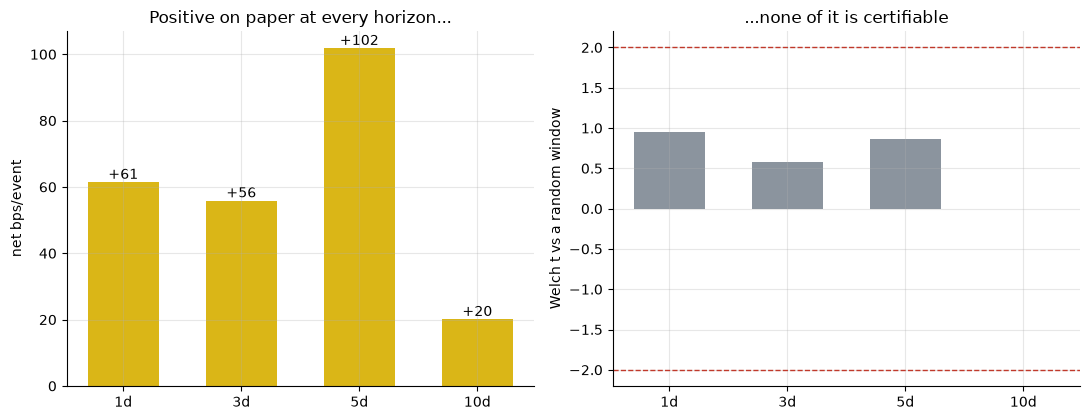

net bps: {1: 61.5, 3: 55.9, 5: 101.8, 10: 20.1}
Welch t: {1: 0.95, 3: 0.57, 5: 0.87, 10: -0.0}
worst %: {1: -16.1, 3: -15.9, 5: -15.9, 10: -29.8}


In [7]:
if HAVE_REAL:
    caps = {h: st.capture_horizon(FXI['AdjClose'], MATCHED_FXI, 'cut', h, 5.0)
            for h in (1, 3, 5, 10)}
    net = [caps[h]['net_bps'] for h in (1, 3, 5, 10)]
    tt = [caps[h]['welch_t'] for h in (1, 3, 5, 10)]
    worst = [caps[h]['worst_pct'] for h in (1, 3, 5, 10)]
else:
    net = [R['timer'][h][1] for h in (1, 3, 5, 10)]
    tt = [R['timer'][h][3] for h in (1, 3, 5, 10)]
    worst = [R['timer'][h][5] for h in (1, 3, 5, 10)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['1d', '3d', '5d', '10d'], net, color=AMBER, width=.6)
for i, v in enumerate(net): a1.annotate(f'{v:+.0f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('net bps/event'); a1.set_title('Positive on paper at every horizon...')
a2.bar(['1d', '3d', '5d', '10d'], tt, color=[RED if abs(t) >= 2 else GREY for t in tt], width=.6)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t vs a random window'); a2.set_title('...none of it is certifiable')
plt.tight_layout(); plt.show()
print('net bps:', dict(zip((1, 3, 5, 10), [round(n, 1) for n in net])))
print('Welch t:', dict(zip((1, 3, 5, 10), [round(t, 2) for t in tt])))
print('worst %:', dict(zip((1, 3, 5, 10), [round(w, 1) for w in worst])))

> 💡 In plain words: every horizon nets positive on paper (best: +102 bps at the 5-day hold) but every single Welch *t* sits well under 2 (best: 0.95). The 10-day hold — long enough to ask "did this survive the news cycle" — nets +20 bps at *t* = -0.00, statistically identical to a random 10-day window, with a **-29.8%** worst-case single event. **H₅ not certified; Tradability = MIRAGE**.

### 4g · Faithful-engine & power control — we know the truth here

Synthetic i.i.d.-return world, scheduled pseudo-cut days every 20th business day, TUNABLE planted mean shift. The null (effect = 0) is checked over **20 seeds**.

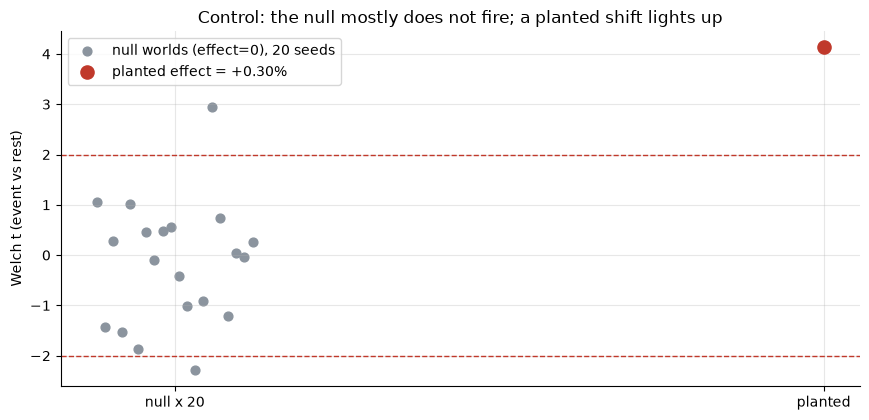

null: mean t = -0.15 (sd 1.22), |t|>=2 in 2/20 seeds  |  planted t = +4.13


In [8]:
null_ts = []
for s_ in range(20):
    close, dec = data.synthetic_world(effect=0.0, seed=647 + s_)
    null_ts.append(st.synthetic_detect(close, dec)['welch_t'])
null_ts = np.asarray(null_ts)
close, dec = data.synthetic_world(effect=0.003, seed=647)
planted_t = st.synthetic_detect(close, dec)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (effect=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted effect = +0.30%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (event vs rest)')
ax.set_title('Control: the null mostly does not fire; a planted shift lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: the null fires in 2/20 seeds — ordinary sampling noise at this seed count, not a biased detector — and a planted shift about the same size as the real cut-day gap reads *t* = 4.13. The machinery works; the real tape's `NONE` verdict is a genuine finding, not a broken pipeline. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — cut-day *t* = 0.99, hike-day *t* = 1.36, neither clears the bar; the decisive **cuts-vs-hikes Welch *t* = 0.09** (MCHI: 0.09) shows the folklore's own distinguishing prediction fails outright. RRR days ARE louder than average (range *t* = +2.45) but direction carries no reliable sign. The one number that clears the bar alone — the 2015-2025 cut-only slice, *t* = 2.10 — is not a certified regime shift (diff *t* = 0.49) and is itself undercut by the wash test.
- **Tradability `MIRAGE`** — no hold length (1/3/5/10 days) reaches *t* = 2; the 10-day hold shows zero excess over a random window (*t* = -0.00) with a -29.8% worst-case tail; FXI's own swap/QFII structure adds fragility on top.
- **"Buy the rumor, sell the news"? `BUSTED`** — pre-cut run-up is *negative* (*t* = -0.97) and the post-cut window shows no clean decay (*t* = -0.71). Not a subtler mechanism to uncover — it simply isn't there.

## 6 · Going further

- **The likely confound.** RRR cuts cluster in stretches when policy is already leaning supportive — property-market stress, growth wobbles, coordinated equity-market support ("national team" buying). That's consistent with the loud-but-directionless pattern here: RRR days correlate with supportive macro windows without the RRR move itself doing the causal work.
- **Where a real edge might live instead:** policy-RATE surprises (the 1yr/5yr LPR fixings) carry more information content per announcement than the RRR, which is largely mechanical and well-telegraphed by State Council pre-announcements — the natural sequel study.
- **Dedup map:** [620-a-h-premium](../../620-a-h-premium/) (structural A/H price gap, no event calendar), [313-geopolitical-shock](../../313-geopolitical-shock/) (same event-study skeleton, a different market and claim entirely — both studies land on `None x Mirage` via the same protocol, a small proof the shared machinery isn't rigged to manufacture positives).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*